In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

# GOAL: to fit spectra in a window around the line. Use XSpec to fit

Here I load the data 

In [2]:
AllData.clear()
path="/home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
#
#Put here the TM you want to use 
#
vfilespectrum = [filespectrumTM1 ,filespectrumTM2,filespectrumTM3,filespectrumTM4,filespectrumTM6]
vfileRMF = [fileRMFTM1 ,fileRMFTM2,fileRMFTM3,fileRMFTM4,fileRMFTM6]
vfileARF = [fileARFTM1 ,fileARFTM2,fileARFTM3,fileARFTM4,fileARFTM6]
#
#LOAD DATA
#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).response = vfileRMF[plot_grp]
    AllData(plot_grp+1).response.arf = vfileARF[plot_grp]

AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 9.345e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.

 response file  read skipped

2 spectra  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_220_SourceSpec_00001.fits  Spectrum 2
Net count rate (cts/s) for Spectrum:2  1.524e+00 +/- 4.091e-03
 Assigned to Data Group 1 and Plot Group 2
  Noticed Chann

Error: cannot read response file srctoolout_120_RMF_00001.fits
Error: cannot read response file srctoolout_220_RMF_00001.fits
Error: cannot read response file srctoolout_320_RMF_00001.fits
Error: cannot read response file srctoolout_420_RMF_00001.fits
Error: cannot read response file srctoolout_620_RMF_00001.fits


Using fit statistic: chi
 Using Response (RMF) File            /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_420_RMF_00001.fits for Source 1
 Using Auxiliary Response (ARF) File  /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_420_ARF_00001.fits

Spectrum 5  Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_620_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:5  1.532e+00 +/- 4.050e-03
 Assigned to Data Group 1 and Plot Group 5
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM6  Channel Type: PI
  Exposure Time: 9.34e+04 sec
 Using fit statistic: chi
 Using Response (RMF) File            /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_620_RMF_00001.fits for Source 1
 U

In [3]:
# PLOT of Aeff for various telescopes

#fig, ax = plt.subplots(figsize=(10,6))
#for i in range (0,len(vfileARF)):
#    arf1test = fits.open(vfileARF[i])['SPECRESP']
#    arf1ELOW = arf1test.data.field('ENERG_LO')#keV
#    arf1EHI = arf1test.data.field('ENERG_HI')#keV
#    arf1Aeff = arf1test.data.field('SPECRESP')#cm2
#    arf1E = (arf1ELOW + arf1EHI)/2.
#    ax.plot(arf1E, arf1Aeff,label='TM')
#ax.set_xlabel('Energy (keV)')
#ax.set_ylabel(r'A_{eff} [cm^2]')
#ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_xlim((0.8,1.5))
#ax.grid()
#ax.legend()

NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [3]:
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
#vE = np.array([1.,10.])
#vFWHM = np.array([0.070,0.165]) #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 2.1 

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  2.1  sigma  0.03679536410063754
Emin  1.9160231794968123  Emax  2.2839768205031876
**-1.916,,2.284-**
Plot command list is now empty
NEbins  40
***************
Selected values  1.920412838459015   2.2738970518112183  Nbins  40
***************
   265 channels (1-265) ignored in spectrum #     1
   265 channels (1-265) ignored in spectrum #     2
   265 channels (1-265) ignored in spectrum #     3
   265 channels (1-265) ignored in spectrum #     4
   265 channels (1-265) ignored in spectrum #     5
   719 channels (306-1024) ignored in spectrum #     1
   719 channels (306-1024) ignored in spectrum #     2
   719 channels (306-1024) ignored in spectrum #     3
   719 channels (306-1024) ignored in spectrum #     4
   719 channels (306-1024) ignored in spectrum #     5

Min Max counts  61   133
***************
Selected values  1.920412838459015   2.2738970518112183  Nbins  40
***************
Min Max counts  60   121
***************
Selected values  1.920412838459015   2.2738970518

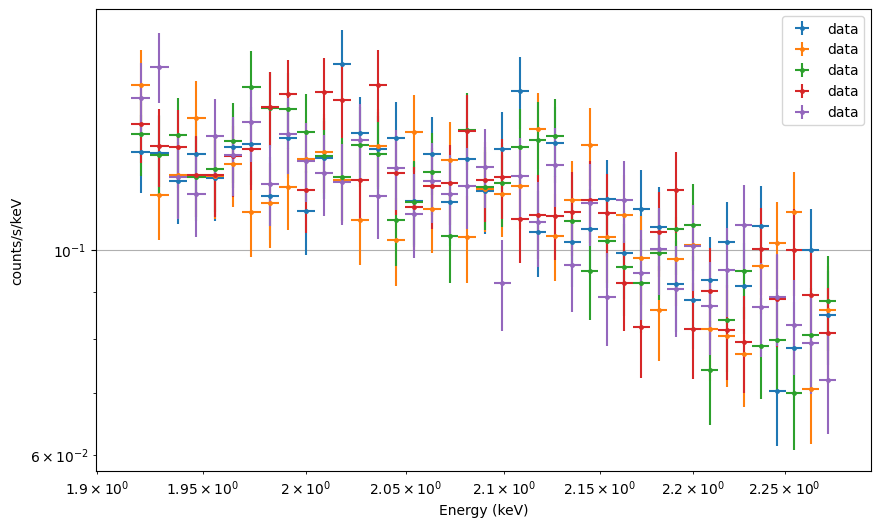

In [5]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [7]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]

ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl

IBn = len(IBLine)
An = len(ALine)
IBAn = IBn + An
IBALine = np.concatenate((IBLine, ALine))
IBALinemin = np.concatenate((IBLinemin, ALinemin))
IBALinemax = np.concatenate((IBLinemax, ALinemax))
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine," IB ",IBLine," A ",ALine)
print(IBALinemin," ",IBALinemax)

Total lines  0  IB  0  A  0
[]  IB  []  A  []
[]   []


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [8]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target
'''
class MTmodel:
    def __init__(self, model, params_name, params_target, fit): #params
        self.model = model
        ##self.params = params
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile setters to eliminate getattr/setattr overhead during evaluate_folded
        self._param_setters = [
            self._make_setter(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_setter(self, obj, attr):
        # Closure that sets obj.attr = value
        def setter(value, obj=obj, attr=attr):
            setattr(obj, attr, value)
        return setter
        
    def set_values(self, params):
        for setter, value in zip(self._param_setters, params):
            setter(value)

    def evaluate_folded(self, params):
        for setter, value in zip(self._param_setters, params):
            setter(value)
        return self.fit.statistic

    def set_frozen(self, keyfits):
        """
        Set the `frozen` attribute of each parameter according to keyfits.
        If keyfits[i] is False -> freeze the parameter (frozen = True). Basically keyfits logic is that True means it is in the Fit
        If keyfits[i] is True  -> let it vary (frozen = False)
        Parameters:
        - keyfits (array-like): A boolean array of same length as params_target indicating
                                whether each parameter should be frozen (True) or not (False).
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for name, attr, keep_free in zip(self.params_name, self.params_target, keyfits):
            param = getattr(getattr(self.model, name), attr)
            param.frozen = not keep_free  # invert the boolean

    def get_values(self):
        values = []
        for name, attr in zip(self.params_name, self.params_target):
            param = getattr(getattr(self.model, name), attr)
            values.append(param.values[0])
        return np.array(values)
'''
class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            param_obj.values = value
        return setter

    #set value of parameters
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers):
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            param.values = [a, 1e-2 * a, b, b, c, c]

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [9]:
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [10]:
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

Normalization factor (can be useful to define limits of the parameters)

In [11]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest
print("normlDMhdata ",normlDMhdata)

normlDMhdata  0.05117390125757081


Create the dictionary of the model

In [12]:
def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}

normline_start= normlDMhdata*0.01
normline_lower = 0.0
normline_upper = normlDMhdata*3
sigmaDM = Eline*220/3e5 #1e-4
sigma_astrolines = 1e-4

# Here I compute the normaliziation of norm*E^(alpha) such that at 1 keV it saturates the data for alpha=0,1,2
startpl = normlDMhdata *np.pow(Eline,0.)
startpl_2 = normlDMhdata *np.pow(Eline,1.)
startpl_3 = normlDMhdata *np.pow(Eline,2.)
upperpl = startpl*10.0
upperpl_2 = startpl_2*10.0
upperpl_3 = startpl_3*10.0
lowerpl = - upperpl
lowerpl_2 = - upperpl_2
lowerpl_3 = - upperpl_3
print("startpl",startpl," ",upperpl," ",lowerpl)
print("startpl_2",startpl_2," ",upperpl_2," ",lowerpl_2)
print("startpl_3",startpl_3," ",upperpl_3," ",lowerpl_3)
#
# I always define DM to be the first gaussian. I set parameters to False (no in the fit)
model_dic = {
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(0.0, 0.0, 0.0, False), # (value, lower, upper, key)
            "norm" : pdic(startpl, lowerpl, upperpl, True)
            },
        "powerlaw_2": {
            "PhoIndex": pdic(1.0, 1.0, 1.0, False), # (value, lower, upper, key)
            "norm" : pdic(startpl_2, lowerpl_2, upperpl_2, True)
            },
        "powerlaw_3": {
            "PhoIndex": pdic(2.0, 2.0, 2.0, False), # (value, lower, upper, key)
            "norm" : pdic(startpl_3, lowerpl_3, upperpl_3, True)
            }
        },
    "gaussian": {
        "gaussian": {
            "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
            "LineE" : pdic(Eline, Eline, Eline, False),
            "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False)
            }
        }
    }
    
    
#ADD gaussian lines
#
# Count all second-level keys in the entire model_dic
start_index_astrol = sum(len(sub_models) for sub_models in model_dic.values())
start_index_astrol = start_index_astrol + 1
print("start_index_astrol ",start_index_astrol)
#
# Start numbering from 2 to avoid conflict with "gaussian"
for i in range(len(IBALine)):
    g_key = f"gaussian_{start_index_astrol + i}"
    model_dic["gaussian"][g_key] = {
        "norm": pdic(normline_start, normline_lower, normline_upper, True),
        "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
    }

# SAVE THE DICTIONARY
#namefile = path_data + 'Initial' + str(iEDM) + ".npy"
#np.save(namefile, model_dic,allow_pickle=True)

startpl 0.05117390125757081   0.5117390125757081   -0.5117390125757081
startpl_2 0.10746519264089871   1.074651926408987   -1.074651926408987
startpl_3 0.2256769045458873   2.256769045458873   -2.256769045458873
start_index_astrol  5


Define the model

In [13]:
# Extract the relevant info from the model dictionary
params,lowers,uppers,params_name,params_target,keyfits = Extract_array_dic(model_dic)

# Create the XSpec model
baseM_parts = []
for top_key, sub_models in model_dic.items():
    count = len(sub_models)  # number of sub-models
    baseM_parts.extend([top_key] * count)  # repeat top_key for each sub-model
#
finalM_xp = '+'.join(baseM_parts)
print("finalM_xp ",finalM_xp)
AllModels.clear()
fullmodel_xp = Model(finalM_xp,"mpoly",1)

Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations=10000
mymodel_all = MTmodel(model=fullmodel_xp,params_name=params_name,params_target=params_target, fit=Fit)
# set the values including the upper and lower limits in Xspec
mymodel_all.set_values_all(params, lowers, uppers)
# set the free parameters in Xspec
mymodel_all.set_frozen(keyfits)

finalM_xp  powerlaw+powerlaw+powerlaw+gaussian

Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.00000      +/-  0.0          
   2    1   powerlaw   norm                1.00000      +/-  0.0          
   3    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   4    2   powerlaw   norm                1.00000      +/-  0.0          
   5    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   6    3   powerlaw   norm                1.00000      +/-  0.0          
   7    4   gaussian   LineE      keV      6.50000      +/-  0.0          
   8    4   gaussian   Sigma      keV      0.100000     +/-  0.0          
   9    4   gaussian   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared              2.998077

In [14]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                5.11739E-02  +/-  0.0          
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                0.107465     +/-  0.0          
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.225677     +/-  0.0          
   7    4   gaussian   LineE      keV      2.10000      frozen
   8    4   gaussian   Sigma      keV      1.54000E-03  frozen
   9    4   gaussian   norm                5.11739E-04  frozen
________________________________________________________________________



In [16]:
#0.10389117272532479   1.038911727253248   -1.038911727253248
#0.11428028999785728   1.1428028999785727   -1.1428028999785727
#0.125708318997643   1.25708318997643   -1.25708318997643

#0.91714752 1.00928032]  IB  []  A  [0.91714752 1.00928032]
#[0.91214752 1.00428032]   [0.92214752 1.01428032]

#print(fullmodel.gaussian_6.Sigma.values)
#print([float(params[0]), float(params[0]*1e-2), float(lowers[0]),float(lowers[0]), float(uppers[0]),float(uppers[0])])

In [17]:
#print(params)
#print(lowers)
#print(uppers)
#print(params_name)
#print(params_target)
#print(keyfits)

In [15]:
# If not already specified in initial dictionarys set DM to False and norm to 0
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)

# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)

# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)
print(params_fit)
print(bounds_fit)
print(keyfits_fit)
print(params_name_fit)
print(params_target_fit)

[0.0511739  0.10746519 0.2256769 ]
[[-0.51173901  0.51173901]
 [-1.07465193  1.07465193]
 [-2.25676905  2.25676905]]
[ True  True  True]
['powerlaw' 'powerlaw_2' 'powerlaw_3']
['norm' 'norm' 'norm']


In [19]:
#startpl 0.10389117272532479   1.038911727253248   -1.038911727253248
#startpl_2 0.11428028999785728   1.1428028999785727   -1.1428028999785727
#startpl_3 0.125708318997643   1.25708318997643   -1.25708318997643

#[0.91714752 1.00928032]  
#[0.91214752 1.00428032]   [0.92214752 1.01428032]

In [16]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                5.11739E-02  +/-  0.0          
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                0.107465     +/-  0.0          
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.225677     +/-  0.0          
   7    4   gaussian   LineE      keV      2.10000      frozen
   8    4   gaussian   Sigma      keV      1.54000E-03  frozen
   9    4   gaussian   norm                0.0          frozen
________________________________________________________________________



In [26]:
TypeFit = 'Diffev' # 'XSpec', 'Minuit', 'Diffev'

In [27]:
def doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit):
    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
    Fit.nIterations=50000

    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)

    if TypeFit == 'XSpec':
        Fit.perform()
        Fit.perform()
        Fit.perform()
        TS_out = Fit.statistic
        nfit = Fit.nVarPars
        dof = Fit.dof
        pvalue = Fit.nullhyp
        params_out = mymodel_fit.get_values()
        #print("Test Statistics ",TS_out," testStatistics ",Fit.testStatistic," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)

    if TypeFit == "Diffev":
        out = optimize.differential_evolution(mymodel_fit.evaluate_folded, bounds_fit, polish = False, 
                                      tol = 1e-4, atol = 0, popsize = 60, init = 'sobol',
                                     maxiter=100000) #maxiter=100000
        params_fit = out.x
        m = Minuit(mymodel_fit.evaluate_folded, params_fit)
        m.limits = bounds_fit
        m.errordef = Minuit.LEAST_SQUARES #i.e. 1
        m.migrad() 
        #display(m.fmin, m.params,m.merrors)
        #params_out = []
        #for p in m.params:
        #    params_out.append(p.value)
        #params_out = np.array(params_out)
        params_out = mymodel_fit.get_values()
        nfit = m.nfit
        dof = len(venergies[0])*len(vfilespectrum) - nfit
        TS_out = m.fval
        pvalue = chi2_scipy.sf(TS_out,dof)
        #print("Test Statistics ",TS_out," testStatistics ",TS_out," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)


    if TypeFit == "Minuit":
        m = Minuit(mymodel_fit.evaluate_folded, params_fit)
        m.limits = bounds_fit 
        m.errordef = Minuit.LEAST_SQUARES #i.e. 1
        m.migrad()
        #params_out = []
        #for p in m.params:
            #params_out.append(p.value)
        #params_out = np.array(params_out)
        params_out = mymodel_fit.get_values()
        nfit = m.nfit
        dof = len(venergies[0])*len(vfilespectrum) - nfit
        TS_out = m.fval
        pvalue = chi2_scipy.sf(TS_out,dof)
        #print("Test Statistics ",TS_out," testStatistics ",TS_out," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)
        
    return (params_out,TS_out,pvalue,dof,nfit)
    

Perform Astrofit

In [28]:
params_astro,TS_astro, pvalue_astro, dof, nfit = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit)

print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof," nVarPars ",nfit)
print("pvalue ",pvalue_astro)
print(params_astro)
print(params_name_fit)
print(params_target_fit)

Test Statistics  426.26382473648914  testStatistics  426.26382473648914  dof  197  nVarPars  3
pvalue  5.828031673043841e-19
[ 0.36426307 -1.07465189  0.87659561]
['powerlaw' 'powerlaw_2' 'powerlaw_3']
['norm' 'norm' 'norm']


In [29]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                0.364263     +/-  0.176599     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                -1.07465     +/-  1.09353      
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.876596     +/-  0.758320     
   7    4   gaussian   LineE      keV      2.10000      frozen
   8    4   gaussian   Sigma      keV      1.54000E-03  frozen
   9    4   gaussian   norm                0.0          frozen
________________________________________________________________________



In [30]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                   81.42     using 40 bins, spectrum 1.
                 C-Statistic                   97.93     using 40 bins, spectrum 2.
                 C-Statistic                   65.50     using 40 bins, spectrum 3.
                 C-Statistic                   97.33     using 40 bins, spectrum 4.
                 C-Statistic                   84.08     using 40 bins, spectrum 5.
Total fit statistic                           426.26     with 197 d.o.f.

Test statistic : Chi-Squared                  393.77     using 200 bins.
 Null hypothesis probability of 3.12e-15 with 197 degrees of freedom
 Current data and model not fit yet.


In [26]:
# xspec
#Test Statistics  236.15808945476  testStatistics  233.63353838090887  dof  198  nVarPars  7
#pvalue  0.04214662034
#[-0.02781616 -0.0295003   0.19180537  0.00944999  0.91600268  0.00312137 1.01428032]

# Minuit
#Test Statistics  235.76069914823665  testStatistics  235.76069914823665  dof  198  nVarPars  7
#pvalue  0.034243450935351104
#[-0.05943195  0.04139894  0.15228612  0.00945768  0.91714752  0.00315233 1.0068832 ]

# Diffev
#Test Statistics  235.16420423407408  testStatistics  235.16420423407408  dof  198  nVarPars  7
#pvalue  0.03632125052410702
#[-0.19286654  0.35034447 -0.02581964  0.01062807  0.91312762  0.00335197
#  1.01049135]
#['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian_5' 'gaussian_5'
# 'gaussian_6' 'gaussian_6']
#['norm' 'norm' 'norm' 'norm' 'LineE' 'norm' 'LineE']

Plot command list is now empty


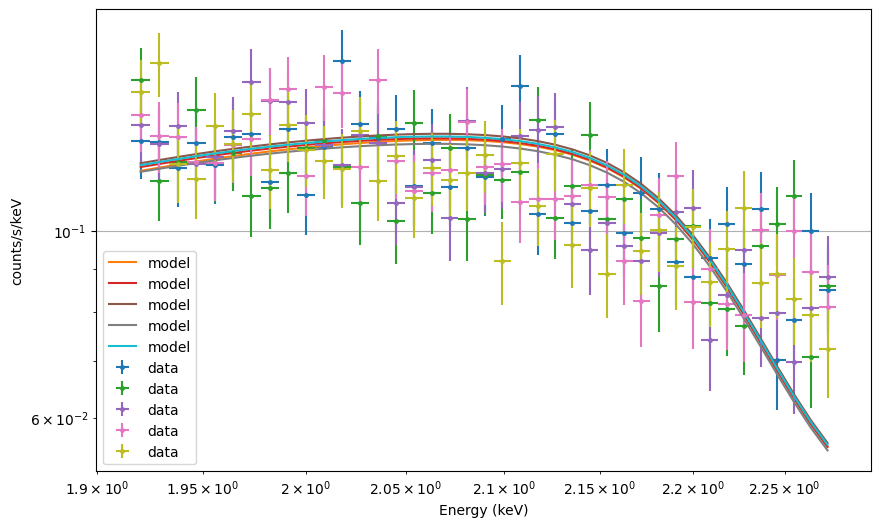

In [31]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

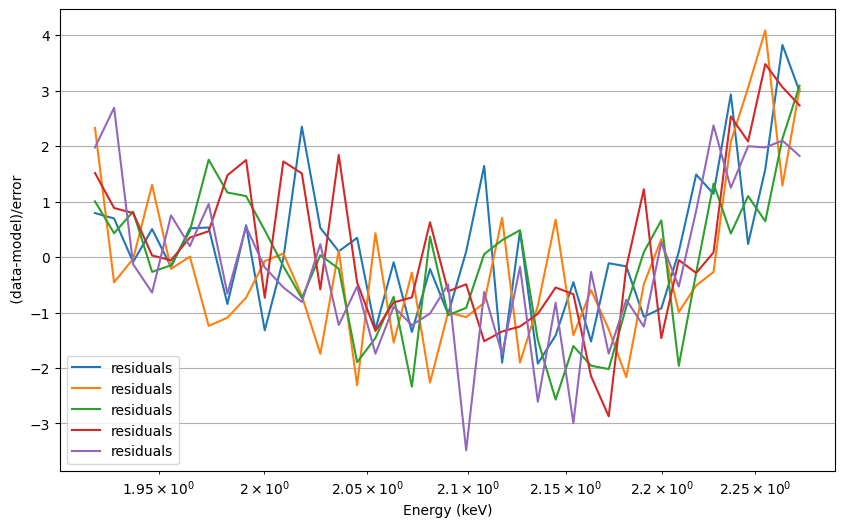

In [32]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  4
0
1
2
3


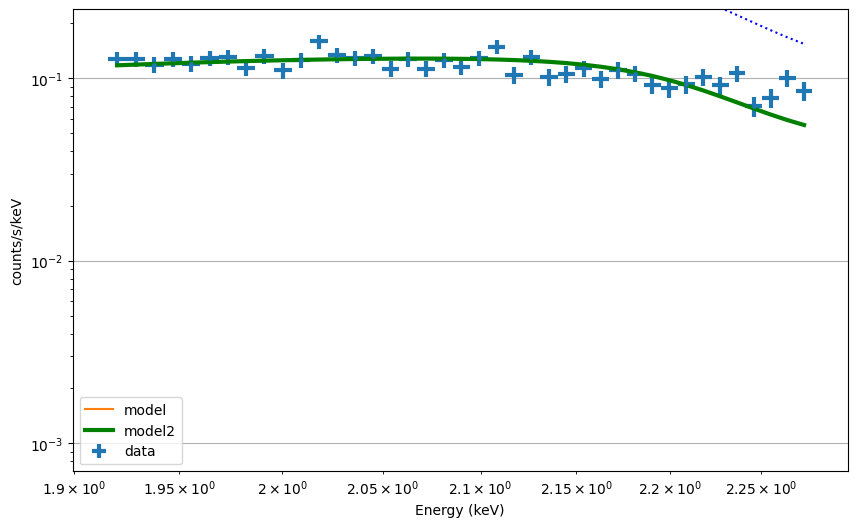

In [33]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model')
ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)


for i in range(0,nAddComps):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

#for i in range(3,nAddComps):
    #print(i)
#    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')

#ax.plot(energiesTMi, modelcomp[2][:],label='',linestyle=':', marker='',color='green')

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.01,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


NOW FIT ASTRO + DM

In [34]:
# Change DM norm and T/F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", True)
change_param_value(params, params_name, params_target, "gaussian", "norm", normline_start)

# set the other parameters to their best-fit value of previous fit
for val, name, attr in zip(params_astro, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)    

# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)

# Select the parameters to Fit. You can check that DM is present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

In [31]:
#[-0.19286654  0.35034447 -0.02581964  0.01062807  0.91312762  0.00335197
#  1.01049135]

In [35]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                0.364263     +/-  0.176599     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                -1.07465     +/-  1.09353      
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.876596     +/-  0.758320     
   7    4   gaussian   LineE      keV      2.10000      frozen
   8    4   gaussian   Sigma      keV      1.54000E-03  frozen
   9    4   gaussian   norm                5.11739E-04  +/-  0.0          
________________________________________________________________________



Peform fit

In [36]:
params_all,TS_all, pvalue_all, dof, nfit = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit)
#
print("Test Statistics ",TS_all," testStatistics ",TS_all," dof ",dof," nVarPars ",nfit)
print("pvalue ",pvalue_all)
print(params_all)
print(params_name_fit)
print(params_target_fit)
#
# Save DM normalization
DMbf = return_param_value(params_all, params_name_fit, params_target_fit, "gaussian", "norm")
print("DM bf ",DMbf)
print("DeltaTS ",TS_astro-TS_all)

Test Statistics  426.2638237708327  testStatistics  426.2638237708327  dof  196  nVarPars  4
pvalue  3.930284313376085e-19
[ 3.64258901e-01 -1.07465189e+00  8.76645619e-01  6.17014166e-10]
['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian']
['norm' 'norm' 'norm' 'norm']
DM bf  6.170141660700614e-10
DeltaTS  9.656564543547574e-07


In [34]:
#XSpec
#Test Statistics  230.92605015478813  testStatistics  230.92605015478813  dof  197  nVarPars  8
#pvalue  0.06319776891
#[-2.10284741e-02 -2.90392294e-02  1.80340608e-01  3.14961443e-04
#  1.05068909e-02  9.12147517e-01  3.43130327e-03  1.01428032e+00]
#['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian' 'gaussian_5' 'gaussian_5'
# 'gaussian_6' 'gaussian_6']
#['norm' 'norm' 'norm' 'norm' 'norm' 'LineE' 'norm' 'LineE']
#DM bf  0.0003149614429582906
#DeltaTS  5.232039299971859

#minuit
#Test Statistics  228.79635884163554  testStatistics  228.79635884163554  dof  197  nVarPars  8
#pvalue  0.05983482100423874
#[-3.67916753e-02  3.95930594e-02  1.20686669e-01  5.60338985e-04
#  1.22540928e-02  9.17147517e-01  3.96638397e-03  1.00858915e+00]
#['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian' 'gaussian_5' 'gaussian_5'
# 'gaussian_6' 'gaussian_6']
#['norm' 'norm' 'norm' 'norm' 'norm' 'LineE' 'norm' 'LineE']
#DM bf  0.0005603389848851512
#DeltaTS  6.964340306601116

# Diffev
#Test Statistics  228.78246830878743  testStatistics  228.78246830878743  dof  197  nVarPars  8
#pvalue  0.0599101696848319
#[-5.83118950e-02  8.82271236e-02  9.34069909e-02  5.49377193e-04
#  1.23751211e-02  9.13196601e-01  3.97916585e-03  1.01325685e+00]
#['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian' 'gaussian_5' 'gaussian_5'
# 'gaussian_6' 'gaussian_6']
#['norm' 'norm' 'norm' 'norm' 'norm' 'LineE' 'norm' 'LineE']
#DM bf  0.0005493771934364643
#DeltaTS  6.381818357962629

In [37]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                0.364259     +/-  0.176599     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                -1.07465     +/-  1.09353      
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.876646     +/-  0.758320     
   7    4   gaussian   LineE      keV      2.10000      frozen
   8    4   gaussian   Sigma      keV      1.54000E-03  frozen
   9    4   gaussian   norm                6.17014E-10  +/-  0.0          
________________________________________________________________________



In [38]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                   81.40     using 40 bins, spectrum 1.
                 C-Statistic                   97.96     using 40 bins, spectrum 2.
                 C-Statistic                   65.51     using 40 bins, spectrum 3.
                 C-Statistic                   97.30     using 40 bins, spectrum 4.
                 C-Statistic                   84.10     using 40 bins, spectrum 5.
Total fit statistic                           426.26     with 196 d.o.f.

Test statistic : Chi-Squared                  393.87     using 200 bins.
 Null hypothesis probability of 2.13e-15 with 196 degrees of freedom
 Current data and model not fit yet.


Plot command list is now empty


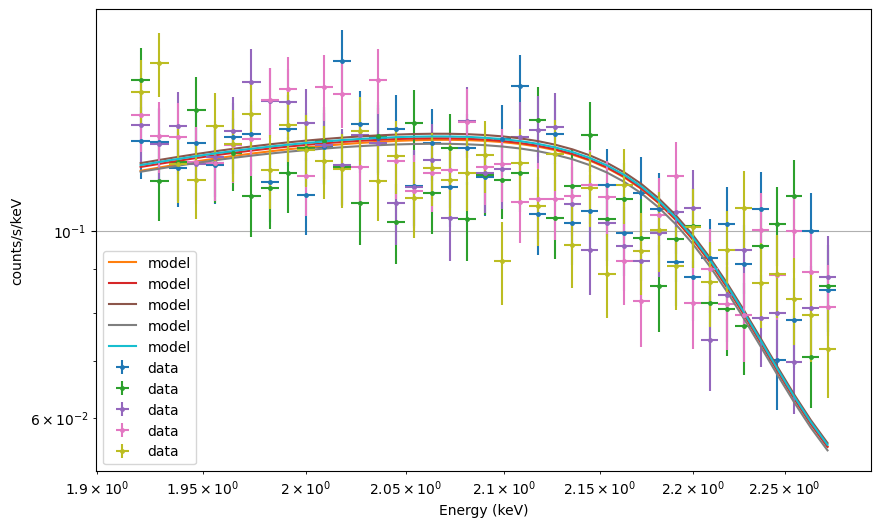

In [39]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

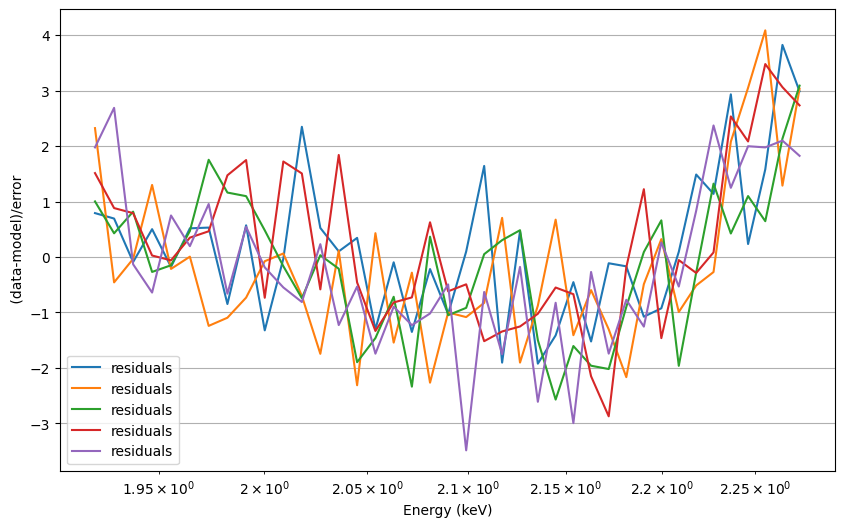

In [40]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  4
0
1
2
3


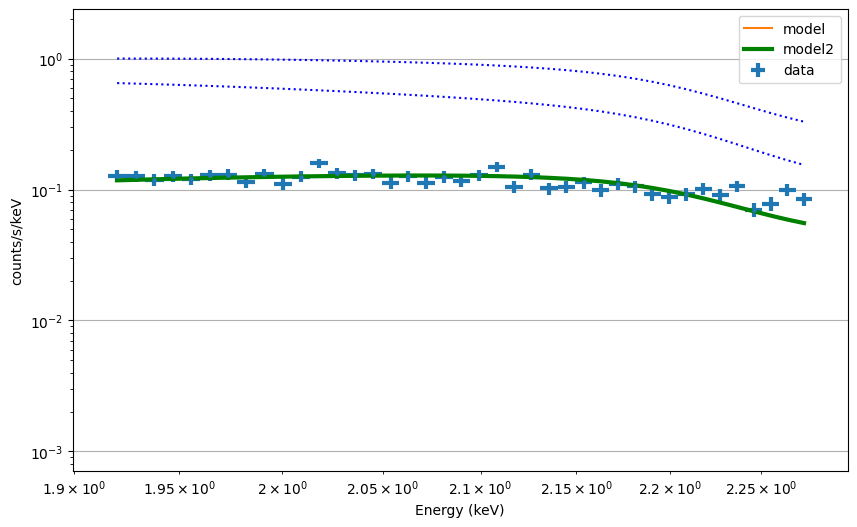

In [ ]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model')
ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)


for i in range(0,nAddComps):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

#for i in range(3,nAddComps):
    #print(i)
#    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')

#ax.plot(energiesTMi, modelcomp[2][:],label='',linestyle=':', marker='',color='green')

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.01,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()

Perform an approximate profiling

In [43]:
TSth = 2.71
def MTroots(vx,vy):
    vroots = []
    for i in range(1,len(vx)):
        #print("vx ",vx[i]," ",vy[i])
        #Check whether sign has changed
        if(vy[i]*vy[i-1]<0.):
            root=(vx[i]*vy[i-1]-vx[i-1]*vy[i])/(vy[i-1]-vy[i])
            #print(vx[i-1]," ",vx[i]," ",vy[i-1]," ",vy[i])
            #print("i ", i," ",root," ")
            vroots.append(root)
    return  vroots

def chi2approx(fullmodel_xp, params_fit, params_name_fit, params_target_fit, A):
    # Change DM normalization
    params_inside = params_fit
    change_param_value(params_inside, params_name_fit, params_target_fit, "gaussian", "norm", A)
    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)
    # evaluation
    res = mymodel_fit.evaluate_folded(params_inside)
    return res

def ApproximateBound(model_final, DMbf, normlDMhdata, nstepsDM, TS_all, params_fit, params_name_fit, params_target_fit):
    start = np.max(np.array([DMbf,normlDMhdata*1e-5]))
    end = normlDMhdata
    profile_range = np.logspace(np.log10(start), np.log10(end), num = nstepsDM)
    TS_vals = np.zeros_like(profile_range)
    for i, A in enumerate(profile_range):
        TS_vals[i] = chi2approx(model_final, params_fit, params_name_fit, params_target_fit, A)
        #print("A TS ",A," ",TS_vals[i])
    x = np.log10(profile_range)
    y = TS_vals - TS_all - TSth
    vroots = np.pow(10.,MTroots(x,y))
    if(len(vroots)>0):
        bound_approx=np.max(vroots)
    else:
        bound_approx=0.
    return bound_approx


In [44]:
# set the parameters to their best-fit value of previous fit with DM
for val, name, attr in zip(params_all, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)  

# since you have changed norm update XSpec 
mymodel_all.set_values_all(params, lowers, uppers)

# Select the parameters to Fit. You can check that DM is still present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

In [45]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          +/-  0.0          
   2    1   powerlaw   norm                0.364259     +/-  0.176599     
   3    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   4    2   powerlaw   norm                -1.07465     frozen
   5    3   powerlaw   PhoIndex            2.00000      +/-  0.0          
   6    3   powerlaw   norm                0.876646     +/-  0.758320     
   7    4   gaussian   LineE      keV      2.10000      +/-  0.0          
   8    4   gaussian   Sigma      keV      1.54000E-03  +/-  0.0          
   9    4   gaussian   norm                6.17014E-10  +/-  0.0          
________________________________________________________________________



In [43]:
#[-3.67916753e-02  3.95930594e-02  1.20686669e-01  5.60338985e-04
#  1.22540928e-02  9.17147517e-01  3.96638397e-03  1.00858915e+00]

#[-5.83118950e-02  8.82271236e-02  9.34069909e-02  5.49377193e-04
#  1.23751211e-02  9.13196601e-01  3.97916585e-03  1.01325685e+00]

In [46]:
# #### Approximate bound: PASS ARRAYS _all referring to best fit model
nstepsDM = 100 # can be a bit larger since it just a matter of evaluations
bound_approx = ApproximateBound(fullmodel_xp, DMbf, normlDMhdata, nstepsDM, TS_all, params_fit, params_name_fit, params_target_fit)
print("Approximate bound ",bound_approx)

Approximate bound  1.608582249352723e-05


Proper profiling

In [47]:
# set the parameters to their best-fit value of global fit with DM (also norm DM)
for val, name, attr in zip(params_all, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)  

# Change DM  T/F setting to F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)


# since you have changed norm and key(True/False), update XSpec
mymodel_all.set_values_all(params, lowers, uppers)
mymodel_all.set_frozen(keyfits)

# Parameters should be at bf value of fit Astro+DM. Simple check that evaluations gives correct TS
print("TS now ",mymodel_all.evaluate_folded(params)," TS_all ",TS_all)

# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

TS now  426.2640373935535  TS_all  426.2638237708327


In [48]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                0.364259     +/-  0.176599     
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                -1.07465     +/-  1.09353      
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.876646     +/-  0.758320     
   7    4   gaussian   LineE      keV      2.10000      frozen
   8    4   gaussian   Sigma      keV      1.54000E-03  frozen
   9    4   gaussian   norm                6.17014E-10  frozen
________________________________________________________________________



In [47]:
#[-3.67916753e-02  3.95930594e-02  1.20686669e-01  5.60338985e-04
#  1.22540928e-02  9.17147517e-01  3.96638397e-03  1.00858915e+00]

#[-5.83118950e-02  8.82271236e-02  9.34069909e-02  5.49377193e-04
#  1.23751211e-02  9.13196601e-01  3.97916585e-03  1.01325685e+00]

In [49]:
print("bound_approx", bound_approx)
print("DM bf ",DMbf)
nstepsDM = 10
start = bound_approx/10.
end = bound_approx*100
profile_range = np.logspace(np.log10(start), np.log10(end), num = nstepsDM)
TS_vals = np.zeros_like(profile_range)
for i, A in enumerate(profile_range):
        #set DM norm
        fullmodel_xp.gaussian.norm = A
        params_inside,TS_inside, pvalue_inside, dof_inside, nfit_inside = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit, TypeFit)
        TS_vals[i] = TS_inside
        # update params to new best fit
        params_fit = params_inside
        print(i, A, TS_vals[i], TS_vals[i] - TS_all)

bound_approx 1.608582249352723e-05
DM bf  6.170141660700614e-10
0 1.6085822493527232e-06 426.5304031913517 0.2665794205190082
1 3.465585399775022e-06 426.83856864551404 0.5747448746813575
2 7.466377406543332e-06 427.5048471131347 1.2410233423020145
3 1.608582249352723e-05 428.9496832729183 2.685859502085634
4 3.465585399775022e-05 432.1067384919201 5.842914721087425
5 7.466377406543332e-05 439.1151919733469 12.851368202514209
6 0.0001608582249352723 455.16694891257475 28.903125141742066
7 0.00034655853997750223 494.11730255716077 67.85347878632808
8 0.0007466377406543324 597.7758107800842 171.51198700925147
9 0.0016085822493527233 907.5155628860313 481.2517391151986
